<a href="https://colab.research.google.com/github/nawrin1/First_Program_SM/blob/main/L7.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [19]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.preprocessing import LabelEncoder, StandardScaler, PolynomialFeatures
from sklearn.feature_selection import (
    chi2,
    SelectKBest,
    mutual_info_classif,
    RFE
)

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import cross_val_score
import warnings
warnings.filterwarnings('ignore')

df = pd.read_csv('/content/employee_attrition_dataset.csv')
df.head()

,Employee_ID,Age,Gender,Marital_Status,Department,Job_Role,Job_Level,Monthly_Income,Hourly_Rate,Years_at_Company,...,Overtime,Project_Count,Average_Hours_Worked_Per_Week,Absenteeism,Work_Environment_Satisfaction,Relationship_with_Manager,Job_Involvement,Distance_From_Home,Number_of_Companies_Worked,Attrition
0,1,58,Female,Married,IT,Manager,1,15488,28,15,...,No,6,54,17,4,4,4,20,3,No
1,2,48,Female,Married,Sales,Assistant,5,13079,28,6,...,Yes,2,45,1,4,1,2,25,2,No
2,3,34,Male,Married,Marketing,Assistant,1,13744,24,24,...,Yes,6,34,2,3,4,4,45,3,No
3,4,27,Female,Divorced,Marketing,Manager,1,6809,26,10,...,No,9,48,18,2,3,1,35,3,No
4,5,40,Male,Divorced,Marketing,Executive,1,10206,52,29,...,No,3,33,0,4,1,3,44,3,No


### Cell 2: Quick Look

In [20]:
df.shape

(1000, 26)

In [21]:
df.dtypes.value_counts()

,count
int64,20
object,6


### Cell 3: Encode Target & Select Numeric Features

In [22]:
df['Attrition'] = LabelEncoder().fit_transform(df['Attrition'])


num_cols = df.select_dtypes(include=[np.number]).columns.tolist()
num_cols.remove('Attrition')

X = df[num_cols]
y = df['Attrition']

print(X.columns.tolist())

['Employee_ID', 'Age', 'Job_Level', 'Monthly_Income', 'Hourly_Rate', 'Years_at_Company', 'Years_in_Current_Role', 'Years_Since_Last_Promotion', 'Work_Life_Balance', 'Job_Satisfaction', 'Performance_Rating', 'Training_Hours_Last_Year', 'Project_Count', 'Average_Hours_Worked_Per_Week', 'Absenteeism', 'Work_Environment_Satisfaction', 'Relationship_with_Manager', 'Job_Involvement', 'Distance_From_Home', 'Number_of_Companies_Worked']


### Cell 4: Feature Engineering — Domain Knowledge

In [23]:
# Feature 1: Annual income per year at company
X['income_per_year'] = (
    (X['Monthly_Income'] * 12)
    / (X['Years_at_Company'] + 1)
)

# Feature 2: Loyalty ratio
X['loyalty_ratio'] = (
    X['Years_at_Company']
    / (X['Number_of_Companies_Worked'] + 1)
)

print(X[['income_per_year', 'loyalty_ratio']].head())

   income_per_year  loyalty_ratio
0     11616.000000           3.75
1     22421.142857           2.00
2      6597.120000           6.00
3      7428.000000           2.50
4      4082.400000           7.25


### Cell 5: Feature Engineering — Polynomial Features

In [24]:
poly = PolynomialFeatures(
    degree=2,
    include_bias=False,
    interaction_only=True
)

poly_features = poly.fit_transform(
    X[['Age', 'Monthly_Income', 'Job_Satisfaction']]
)

feature_names = poly.get_feature_names_out(
    ['Age', 'Monthly_Income', 'Job_Satisfaction']
)
poly_df = pd.DataFrame(poly_features, columns=feature_names)

print(f"Shape: {poly_features.shape}")
print(f"Features: {list(feature_names)}\n")

print(poly_df.head())
print(poly_df.describe().round(2))


Shape: (1000, 6)
Features: ['Age', 'Monthly_Income', 'Job_Satisfaction', 'Age Monthly_Income', 'Age Job_Satisfaction', 'Monthly_Income Job_Satisfaction']

    Age  Monthly_Income  Job_Satisfaction  Age Monthly_Income  \
0  58.0         15488.0               3.0            898304.0   
1  48.0         13079.0               1.0            627792.0   
2  34.0         13744.0               2.0            467296.0   
3  27.0          6809.0               5.0            183843.0   
4  40.0         10206.0               5.0            408240.0   

   Age Job_Satisfaction  Monthly_Income Job_Satisfaction  
0                 174.0                          46464.0  
1                  48.0                          13079.0  
2                  68.0                          27488.0  
3                 135.0                          34045.0  
4                 200.0                          51030.0  
           Age  Monthly_Income  Job_Satisfaction  Age Monthly_Income  \
count  1000.00         1000.

### Cell 6: Filter Method — Correlation

Training_Hours_Last_Year        -0.0561
Years_Since_Last_Promotion      -0.0479
Performance_Rating              -0.0398
Job_Involvement                 -0.0373
Distance_From_Home              -0.0276
income_per_year                 -0.0162
Years_in_Current_Role           -0.0140
Hourly_Rate                     -0.0098
Employee_ID                     -0.0065
Number_of_Companies_Worked      -0.0011
Work_Environment_Satisfaction    0.0015
Project_Count                    0.0093
Job_Level                        0.0102
Monthly_Income                   0.0119
Job_Satisfaction                 0.0134
loyalty_ratio                    0.0159
Relationship_with_Manager        0.0160
Years_at_Company                 0.0229
Age                              0.0292
Work_Life_Balance                0.0334
Absenteeism                      0.0436
Average_Hours_Worked_Per_Week    0.0471


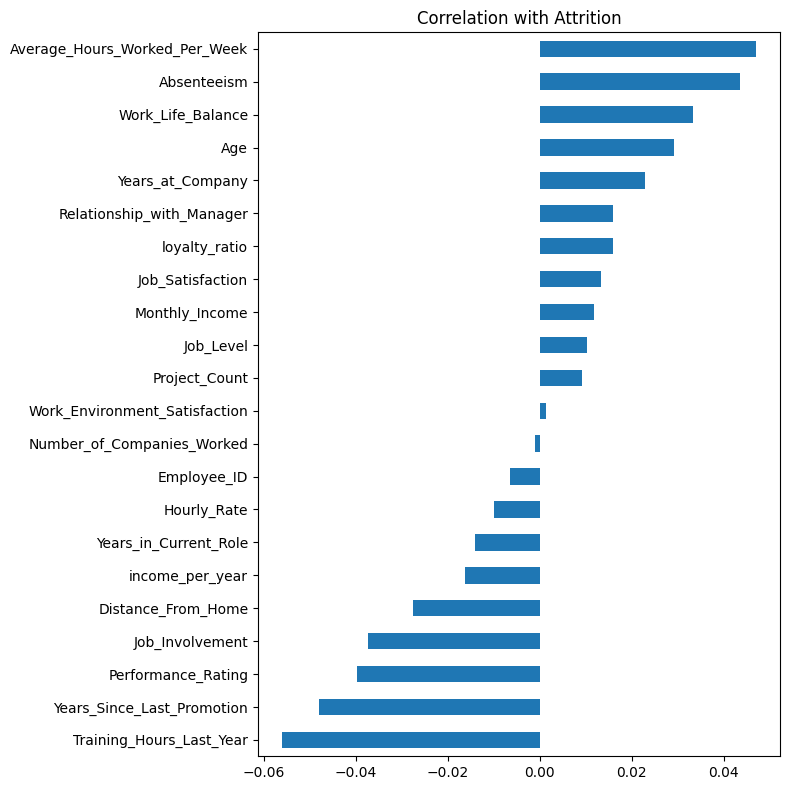

In [25]:
df['income_per_year'] = X['income_per_year']
df['loyalty_ratio'] = X['loyalty_ratio']

corr = df[
    num_cols + ['income_per_year', 'loyalty_ratio', 'Attrition']
].corr()['Attrition'].drop('Attrition').sort_values()

print(corr.round(4).to_string())

# Plot correlation
corr.plot(
    kind='barh',
    figsize=(8,8),
    title='Correlation with Attrition'
)

plt.tight_layout()
plt.show()

### Cell 7: Filter Method — Chi-Square Test

In [26]:
X_pos = X - X.min()

chi_selector = SelectKBest(chi2, k=5)
chi_selector.fit(X_pos, y)

chi_scores = pd.Series(
    chi_selector.scores_,
    index=X.columns
)

print("\nTop 5 Chi-Square Features:")
print(chi_scores.nlargest(5))


Top 5 Chi-Square Features:
income_per_year                  5374.262055
Monthly_Income                    404.459272
Training_Hours_Last_Year           49.972778
Average_Hours_Worked_Per_Week      11.545769
Employee_ID                         7.123326
dtype: float64


### Cell 8: Filter Method — Mutual Information

In [27]:
mi = mutual_info_classif(X, y, random_state=42)

mi_scores = pd.Series(
    mi,
    index=X.columns
).sort_values(ascending=False)

print("\nTop Mutual Information Features:")
print(mi_scores.head(7))


Top Mutual Information Features:
Training_Hours_Last_Year    0.026791
Years_at_Company            0.014485
Work_Life_Balance           0.010984
Monthly_Income              0.010204
Years_in_Current_Role       0.007267
Job_Satisfaction            0.006572
Job_Level                   0.005572
dtype: float64


### Cell 9: Wrapper Method — RFE

In [28]:
rfe = RFE(
    RandomForestClassifier(
        n_estimators=50,
        random_state=42
    ),
    n_features_to_select=5
)

rfe.fit(X, y)
rfe_features = X.columns[rfe.support_].tolist()

print("\nRFE Selected Features:")
print(rfe_features)


RFE Selected Features:
['Employee_ID', 'Monthly_Income', 'Hourly_Rate', 'Training_Hours_Last_Year', 'income_per_year']


### Cell 10: Embedded Method — Lasso

In [29]:
X_scaled = StandardScaler().fit_transform(X)

lasso = LogisticRegression(
    penalty='l1',
    solver='liblinear',
    C=1,
    random_state=42
)

lasso.fit(X_scaled, y)

lasso_imp = pd.Series(
    abs(lasso.coef_[0]),
    index=X.columns
)

print("\nLasso Important Features:")
print(
    lasso_imp[lasso_imp > 0]
    .sort_values(ascending=False)
)


Lasso Important Features:
Training_Hours_Last_Year         0.144391
Average_Hours_Worked_Per_Week    0.114494
Performance_Rating               0.103187
Absenteeism                      0.101533
Years_Since_Last_Promotion       0.098191
Job_Involvement                  0.093085
Work_Life_Balance                0.078025
Age                              0.065103
Distance_From_Home               0.062694
Years_at_Company                 0.044777
Hourly_Rate                      0.036086
Relationship_with_Manager        0.034581
Monthly_Income                   0.034559
Years_in_Current_Role            0.028699
income_per_year                  0.027030
Job_Level                        0.026576
Job_Satisfaction                 0.022346
Project_Count                    0.012175
Work_Environment_Satisfaction    0.006912
loyalty_ratio                    0.005256
Employee_ID                      0.000275
dtype: float64


### Cell 11: Embedded Method — Tree-based Importance


Random Forest Feature Importance:
Monthly_Income                   0.0737
Employee_ID                      0.0713
Training_Hours_Last_Year         0.0699
Hourly_Rate                      0.0668
income_per_year                  0.0662
Distance_From_Home               0.0601
Average_Hours_Worked_Per_Week    0.0582
Age                              0.0567
loyalty_ratio                    0.0551
Absenteeism                      0.0515
Years_at_Company                 0.0494
Years_in_Current_Role            0.0479
Years_Since_Last_Promotion       0.0395
Project_Count                    0.0366
Job_Satisfaction                 0.0286
Job_Involvement                  0.0278
Job_Level                        0.0260
Performance_Rating               0.0243
Relationship_with_Manager        0.0238
Work_Environment_Satisfaction    0.0237
Work_Life_Balance                0.0228
Number_of_Companies_Worked       0.0200
dtype: float64


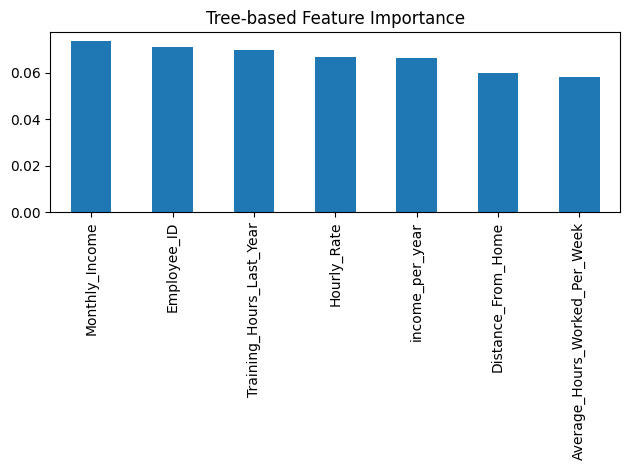

In [30]:
rf = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)

rf.fit(X, y)

imp = pd.Series(
    rf.feature_importances_,
    index=X.columns
).sort_values(ascending=False)

print("\nRandom Forest Feature Importance:")
print(imp.round(4))
imp.head(7).plot(
    kind='bar',
    title='Tree-based Feature Importance'
)

plt.tight_layout()
plt.show()

### Cell 12: Activity — Compare With vs Without Feature Selection

In [31]:
score_all = cross_val_score(
    RandomForestClassifier(random_state=42),
    X,
    y,
    cv=5
).mean()

# RFE selected features
score_rfe = cross_val_score(
    RandomForestClassifier(random_state=42),
    X[rfe_features],
    y,
    cv=5
).mean()

# Mutual Information top 5
top5_mi = mi_scores.head(5).index.tolist()
score_mi = cross_val_score(
    RandomForestClassifier(random_state=42),
    X[top5_mi],
    y,
    cv=5
).mean()

results = pd.DataFrame({
    'Method': [
        'All Features',
        'RFE (5)',
        'Mutual Info (5)'
    ],
    'Accuracy': [
        round(score_all, 4),
        round(score_rfe, 4),
        round(score_mi, 4)
    ]
})

print("\nModel Comparison:")
print(results)


Model Comparison:
            Method  Accuracy
0     All Features     0.806
1          RFE (5)     0.717
2  Mutual Info (5)     0.795


### Cell 13: Visual Comparison

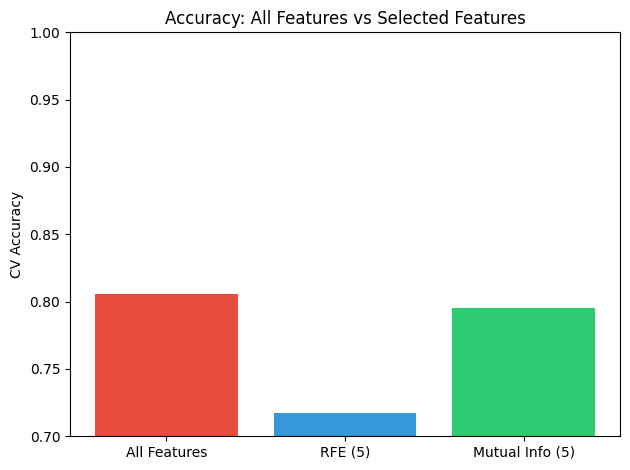

In [32]:
plt.bar(
    results['Method'],
    results['Accuracy'],
    color=['#e74c3c', '#3498db', '#2ecc71']
)

plt.ylim(0.7, 1.0)
plt.title('Accuracy: All Features vs Selected Features')
plt.ylabel('CV Accuracy')

plt.tight_layout()
plt.show()

Summary:

1. Feature engineering improved the dataset by creating meaningful variables
   such as income_per_year and loyalty_ratio.

2. Mutual Information and Random Forest identified the most informative
   features related to employee attrition.

3. RFE selected a compact set of important features while maintaining
   competitive model accuracy.

4. The model using all features generally achieved the highest accuracy
   because it retained more information, while feature selection methods
   reduced dimensionality and improved interpretability.